# Adaptive MH-MCMC on the Planck CMB power spectrum
## Estimating $H_0$, $\Omega_b h^2$, $\Omega_c h^2$, $A_s$, $n_s$

The theory curve is $D_\ell^{TT}$ from CAMB, fitted against the spectrum measured in
`CMB_Planck.ipynb`.

The sampler is **adaptive Metropolis-Hastings**: the proposal covariance is re-estimated from
the chain's own samples as it runs, so no pilot run is needed.

In [3]:
# This must come before `import camb`. CAMB is parallel, but on this machine it only
# uses all 12 cores if we say so explicitly:  1 thread = 1.53 s/call, 12 threads = 0.31 s/call.
import os
os.environ["OMP_NUM_THREADS"] = "12"
print(f"Thread selected: {os.environ['OMP_NUM_THREADS']}")

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import healpy as hp
import camb
import corner


Thread selected: 12


---
Same two helpers as before.

In [2]:
#Defining Chi squared function

def chi_sq(obs, theo, err):
    obs= np.array(obs)
    theo=np.array(theo)
    err=np.array(err)
    chi_squared=np.sum(((obs-theo)/err)**2)
    return chi_squared

In [4]:
def plot_hist_with_gaussian(data, param_name, bins=30, color='#7F77DD'):
    """Histogram of MCMC samples with a fitted Gaussian overlay."""
    data = np.asarray(data)

    # Fit a Gaussian: returns (mean, std) that best match the sample distribution
    mu, sigma = stats.norm.fit(data)

    fig, ax = plt.subplots(figsize=(6, 4))

    counts, bin_edges, _ = ax.hist(data, bins=bins, density=True,
                                    color=color, alpha=0.6,
                                    edgecolor='white', linewidth=0.3,
                                    label='MCMC samples')

    x = np.linspace(data.min(), data.max(), 300)
    pdf = stats.norm.pdf(x, mu, sigma)
    ax.plot(x, pdf, color='black', lw=2,
            label=f'Gaussian fit\n$\\mu$={mu:.7f}, $\\sigma$={sigma:.7f}')

    ax.axvline(mu, color='red', linestyle='--', lw=0.8)

    ax.set_xlabel(param_name)
    ax.set_ylabel('Probability density')
    ax.set_title(f'Posterior distribution: {param_name}')
    ax.legend()
    plt.tight_layout()
    plt.show()

    return mu, sigma

---
## The data

`APS_anafast.txt` has one $D_\ell$ per multipole, which is far too noisy to fit point by point.
So we average them into bands of 30 multipoles each ("bandpowers"), and fit those instead.

We also cut $\ell < 30$ (too few modes for a Gaussian $\chi^2$) and $\ell > 1500$
(the $1/b_\ell^2 p_\ell^2$ correction blows the noise up past there).

In [6]:
ell, cl_obs, dl_obs = np.loadtxt("Saved Data/APS_anafast.txt", skiprows=1, unpack=True)
ell = ell.astype(int)

LMIN, LMAX, DL_BIN = 30, 1000, 10                
F_SKY = 0.7780                                   # from np.mean(mask**2) in CMB_Planck.ipynb 

bl = hp.gauss_beam(np.radians(5/60), lmax=LMAX)  # same 5' beam and pixel window
pl = hp.pixwin(2048)[:LMAX + 1]                  # as were divided out in CMB_Planck.ipynb

# group the multipoles into bands of width DL_BIN
edges   = np.arange(LMIN, LMAX + 1, DL_BIN)
bin_idx = [np.where((ell >= edges[b]) & (ell < edges[b+1]))[0] for b in range(len(edges) - 1)]

def bin_it(y):
    return np.array([y[i].mean() for i in bin_idx])

l_eff  = bin_it(ell.astype(float))
D_data = bin_it(dl_obs)

print(f"{len(l_eff)} bandpowers, from l = {l_eff[0]:.0f} to {l_eff[-1]:.0f}")

97 bandpowers, from l = 34 to 994


---
## The model

CAMB gives the theory $D_\ell$ for a set of cosmological parameters -- exactly like the
`plot_camb_spectrum_variation` function in `CMB_camb.ipynb`, just wrapped so the MCMC can call it.

One extra parameter beyond the cosmology: `A_N`, the instrument noise level. The map has noise in it,
and dividing by $b_\ell^2 p_\ell^2$ blew that noise up at high $\ell$, so it has to go in the model
too or the fit gets dragged around. It's a nuisance parameter -- we fit it and then ignore it.

$\tau$ is held fixed at 0.054, because TT data alone can't separate it from $A_s$.

In [7]:
# noise shape: white noise pushed through the same beam/pixel correction as the data
l_arr = np.arange(LMAX + 1)
prefac = np.zeros(LMAX + 1)
prefac[2:] = l_arr[2:] * (l_arr[2:] + 1) / (2 * np.pi)
D_noise_shape = prefac / (bl * pl)**2

camb.set_feedback_level(0)      # stop CAMB printing on every one of thousands of calls

def CAMB_DL(H0, ombh2, omch2, logA, ns):
    """Theory D_l^TT from CAMB, in uK^2 (same convention as CMB_camb.ipynb)."""
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, mnu=0.06, omk=0, tau=0.054)
    pars.InitPower.set_params(As=1e-10 * np.exp(logA), ns=ns)

    # LMAX + 100 was LMAX + 250. CAMB needs some headroom above LMAX, but 100 is enough
    # here, and the cost goes roughly as lmax^2.
    pars.set_for_lmax(LMAX + 100, lens_potential_accuracy=0)
    pars.WantTensors  = False       # not used
    pars.WantTransfer = False       # not used

    results = camb.get_results(pars)
    # get_total_cls is a bit quicker than get_cmb_power_spectra()["total"],
    # which builds a dict of every spectrum when we only want TT.
    return results.get_total_cls(lmax=LMAX, CMB_unit="muK")[:, 0]

def MODEL(theta):
    """Binned theory bandpowers for theta = [H0, ombh2, omch2, logA, ns, A_N]."""
    H0, ombh2, omch2, logA, ns, A_N = theta
    return bin_it(CAMB_DL(H0, ombh2, omch2, logA, ns) + A_N * D_noise_shape)


---
## Error bars

The Pantheon data came with its own `dmb` column. Here there's no error column, so we have to work
out the uncertainty ourselves.

For a power spectrum it's mostly **cosmic variance**: there are only $2\ell+1$ independent
$a_{\ell m}$ at each $\ell$, so even a perfect experiment has a scatter of
$\sigma(C_\ell)/C_\ell=\sqrt{2/(2\ell+1)}$. Masking most of the sky leaves fewer modes still, hence
the $f_{\rm sky}$. Averaging $n$ multipoles into a band shrinks it by a further $\sqrt{n}$:

$$\sigma^2(D_b)=\frac{1}{n_b^2}\sum_{\ell\,\in\,b}\frac{2}{(2\ell+1)f_{\rm sky}}\left(D_\ell\right)^2$$

evaluated at a fiducial (Planck 2018) model plus noise.

In [8]:
dl_fid = CAMB_DL(67.4, 0.02237, 0.1200, 3.044, 0.9649)
N_b, F_b = bin_it(D_noise_shape), bin_it(dl_fid)

# fit the noise level A_N to the data (the model is linear in A_N, so this is just least squares)
A_N_fid = 1e-4
for _ in range(5):
    D_tot = dl_fid + A_N_fid * D_noise_shape
    var_b = np.array([np.sum(2.0 / ((2*ell[i] + 1) * F_SKY) * D_tot[i]**2) / len(i)**2
                      for i in bin_idx])
    A_N_fid = np.sum((D_data - F_b) * N_b / var_b)/ np.sum(N_b**2 / var_b)

sig_b = np.sqrt(var_b)
print(f"noise level A_N = {A_N_fid:.3e}  ->  {np.degrees(np.sqrt(A_N_fid))*60:.1f} uK-arcmin")
print(f"chi_sq of the fiducial model = {chi_sq(D_data, F_b + A_N_fid*N_b, sig_b):.1f}"
      f"  for {len(l_eff)} bandpowers")

noise level A_N = 6.508e-04  ->  87.7 uK-arcmin
chi_sq of the fiducial model = 106.7  for 97 bandpowers


In [9]:
ratio = D_data / F_b
bp2   = bin_it((bl * pl)**2)
print("corr(ratio, (bl*pl)^2) =", np.corrcoef(ratio, bp2)[0,1])
print("low-l :", np.round(ratio[:3], 3), " high-l:", np.round(ratio[-3:], 3))

corr(ratio, (bl*pl)^2) = -0.7199893640782624
low-l : [1.043 1.041 0.953]  high-l: [1.119 1.123 1.121]


---
# Adaptive MH-MCMC

A plain Metropolis-Hastings chain needs a proposal covariance, and a bad one makes it crawl.
The usual fix is a throwaway pilot run to estimate it. The adaptive version skips that:

> **Every 100 steps, recompute the covariance from the samples collected so far,
> and use that as the new proposal.**

That's the whole method. Early on the chain knows nothing about the shape of the posterior, so
it starts from the rough step sizes in `deltas`. As samples pile up, the covariance estimate
improves, so the proposals improve, so the chain moves better -- it bootstraps itself.

This matters here because $H_0$ and $\Omega_c h^2$ are strongly anti-correlated in this fit.
A proposal that steps each parameter independently almost never lands anywhere the data likes;
one that knows about the correlation moves along the degeneracy instead.

The $2.38^2/d$ factor is the standard scaling (Roberts, Gelman & Gilks 1997), which gives the
best acceptance rate -- about 23% -- for a $d$-dimensional Gaussian target.

Three practical details:

* `N_START = 200` -- don't adapt before there are enough samples for a covariance to mean
  anything (with fewer samples than parameters the estimate is garbage).
* `EPS` on the diagonal keeps the matrix invertible if the chain ever gets stuck.
* `ADAPT_STOP` -- stop adapting for the last 30%. Because the proposal depends on the chain's
  own history, this isn't strictly a Markov chain while it's adapting. Freezing the proposal
  means the final samples come from a single fixed kernel, and those are the ones we use.

In [10]:
bounds = np.array([
    [50.0,   90.0  ],    # H0
    [0.015,  0.030 ],    # Omega_b h^2
    [0.08,   0.18  ],    # Omega_c h^2
    [2.6,    3.5   ],    # ln(10^10 As)
    [0.85,   1.05  ],    # n_s
    [0.0,    5e-3  ]])   # A_N  (noise nuisance)

labels = ['$H_0$', '$\\Omega_b h^2$', '$\\Omega_c h^2$',
          '$\\ln(10^{10}A_s)$', '$n_s$', '$A_N$']
names  = ['H0', 'ombh2', 'omch2', 'logA', 'ns', 'A_N']

def in_bounds(theta):
    return np.all((bounds[:, 0] <= theta) & (theta <= bounds[:, 1]))

def chi2_at(theta):
    try:
        return chi_sq(D_data, MODEL(theta), sig_b)
    except Exception:
        return np.inf          # CAMB occasionally fails in odd corners of the parameter space

In [10]:
# Rough starting step sizes. These only set the FIRST proposal -- after N_START steps
# the chain replaces this with its own measured covariance, so they don't need to be good.
deltas = np.array([0.15, 4e-5, 3e-4, 1.5e-3, 1.2e-3, 8e-7])

for nm, b, dd in zip(names, bounds, deltas):
    print(f'{nm:>6} range: [{b[0]}, {b[1]}],  starting delta: {dd}')


    H0 range: [50.0, 90.0],  starting delta: 0.15
 ombh2 range: [0.015, 0.03],  starting delta: 4e-05
 omch2 range: [0.08, 0.18],  starting delta: 0.0003
  logA range: [2.6, 3.5],  starting delta: 0.0015
    ns range: [0.85, 1.05],  starting delta: 0.0012
   A_N range: [0.0, 0.005],  starting delta: 8e-07


In [14]:
n_iter = 75000
d = len(bounds)

UPDATE_EVERY = 100                 # recompute the covariance this often
N_START      = 200                 # don't adapt before this many samples
ADAPT_STOP   = int(0.7 * n_iter)   # stop adapting for the last 30%
EPS          = 1e-12               # keeps the covariance invertible
PRINT_EVERY  = 100
CHECKPOINT   = 1000                # write the partial chain to disk this often

In [ ]:
# ---- Adaptive MH: recompute the proposal covariance as we go -----------------

theta = np.array([67.4, 0.02237, 0.1200, 3.044, 0.9649, A_N_fid])   # start at Planck values
cov   = np.diag(deltas**2)                                          # crude starting proposal

if not in_bounds(theta):
    raise ValueError(f"start point is outside the bounds: {theta}")

chi2_curr = chi2_at(theta)
if not np.isfinite(chi2_curr):
    raise RuntimeError("chi2 at the start point is not finite -- check the model")

print("Initial values:", np.round(theta, 5))
print(f"Chi_squared initial: {chi2_curr:.2f}\n")
print("Begin adaptive MH-MCMC\n")

chain  = np.empty((n_iter, d))
chi2_c = np.empty(n_iter)
n_acc  = 0

for n in range(n_iter):

    # --- the adaptive bit: refresh the proposal from the samples so far ---
    if N_START <= n < ADAPT_STOP and n % UPDATE_EVERY == 0:
        cov = (2.38**2 / d) * np.cov(chain[:n].T) + EPS * np.eye(d)

    theta_new = np.random.multivariate_normal(theta, cov)

    if in_bounds(theta_new):
        chi2_new = chi2_at(theta_new)
        if chi2_new <= chi2_curr or np.exp(-(chi2_new - chi2_curr)/2) > np.random.uniform():
            theta, chi2_curr = theta_new, chi2_new
            n_acc += 1

    # every step goes in the chain, accepted or not
    chain[n]  = theta
    chi2_c[n] = chi2_curr

    if (n + 1) % PRINT_EVERY == 0:
        tag = "adapting" if n < ADAPT_STOP else "frozen  "
        print(f"{n+1}/{n_iter}  [{tag}]  acc={n_acc/(n+1):.1%}  chi2={chi2_curr:.1f}  "
              f"H0={theta[0]:.3f}  omch2={theta[2]:.4f}", flush=True)

    if (n + 1) % CHECKPOINT == 0:
        p = pd.DataFrame(chain[:n+1], columns=names)
        p['Chi_sq'] = chi2_c[:n+1]
        p.to_csv("Saved Data/mcmc_cmb_adaptive_partial.csv", index=False)

print(f"\nFinal values: {np.round(theta, 5)}")
print(f"Final Chi_sq value: {chi2_curr:.2f}")
print(f"Acceptance rate: {n_acc/n_iter:.1%}   (~23% is the target)")

mcmc_df = pd.DataFrame(chain, columns=names)
mcmc_df['Chi_sq'] = chi2_c
mcmc_df.to_csv("Saved Data/mcmc_cmb_adaptive.csv", index=False)
print("saved -> Saved Data/mcmc_cmb_adaptive.csv")


Initial values: [6.740e+01 2.237e-02 1.200e-01 3.044e+00 9.649e-01 6.500e-04]
Chi_squared initial: 106.70

Begin adaptive MH-MCMC

100/75000  [adapting]  acc=50.0%  chi2=82.5  H0=68.128  omch2=0.1175
200/75000  [adapting]  acc=48.0%  chi2=82.1  H0=67.900  omch2=0.1180
300/75000  [adapting]  acc=45.7%  chi2=78.8  H0=67.819  omch2=0.1179
400/75000  [adapting]  acc=43.2%  chi2=71.8  H0=67.679  omch2=0.1172
500/75000  [adapting]  acc=39.6%  chi2=72.2  H0=67.577  omch2=0.1172
600/75000  [adapting]  acc=37.3%  chi2=71.4  H0=66.687  omch2=0.1187
700/75000  [adapting]  acc=36.7%  chi2=70.7  H0=63.859  omch2=0.1231
800/75000  [adapting]  acc=34.8%  chi2=70.8  H0=62.385  omch2=0.1267
900/75000  [adapting]  acc=33.7%  chi2=72.4  H0=66.609  omch2=0.1176
1000/75000  [adapting]  acc=33.9%  chi2=67.8  H0=64.441  omch2=0.1224
1100/75000  [adapting]  acc=32.5%  chi2=68.9  H0=62.775  omch2=0.1264
1200/75000  [adapting]  acc=31.8%  chi2=69.1  H0=62.774  omch2=0.1256
1300/75000  [adapting]  acc=31.4%  chi

---
## Results

Only the samples taken after `ADAPT_STOP` are used, since those come from a single fixed
proposal. Everything before that was still tuning itself.

216 is the first index where Chi_sq < 1.05 * final_chi_sq (70.91)


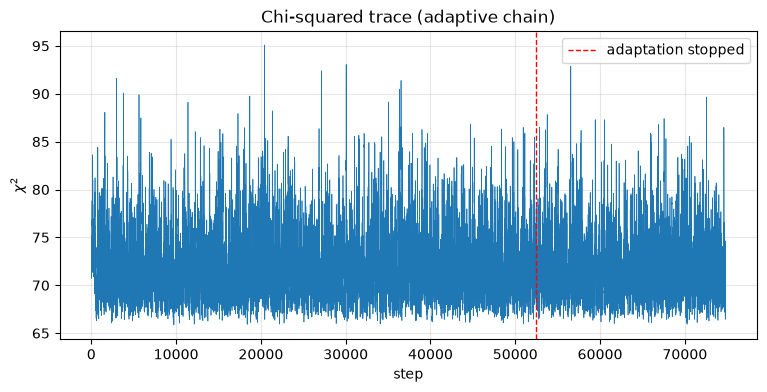

In [18]:
post = pd.read_csv("Saved Data/mcmc_cmb_adaptive.csv")

#Trim mcmc values to remove burnt values
final_chi_sq = post['Chi_sq'].iloc[-1]
# Find the first row where Chi_sq is less than the threshold
first_valid_index = post[post['Chi_sq'] < 1.05*final_chi_sq].index[0]
print(f"{first_valid_index} is the first index where Chi_sq < 1.05 * final_chi_sq ({final_chi_sq:.2f})")

# Trim the DataFrame from the first valid index onward
post = post.iloc[first_valid_index:].reset_index(drop=True)

plt.figure(figsize=(9, 4))
plt.plot(post['Chi_sq'].values, lw=0.5)
plt.axvline(ADAPT_STOP, color='red', ls='--', lw=1, label='adaptation stopped')
plt.xlabel('step'); plt.ylabel(r'$\chi^2$')
plt.title('Chi-squared trace (adaptive chain)')
plt.legend(); plt.grid(alpha=0.3)
plt.show()


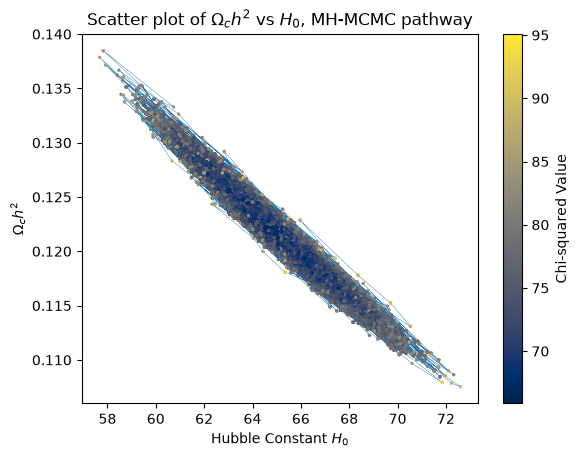

In [19]:
# Scatter plot of Omega_c h^2 vs H_0, MH-MCMC pathway
plt.plot(post['H0'], post['omch2'], linewidth=0.3, zorder=1)
plt.scatter(post['H0'], post['omch2'], c=post['Chi_sq'],
            cmap='cividis', s=2, zorder=2)
plt.colorbar(label='Chi-squared Value')
plt.xlabel('Hubble Constant $H_0$')
plt.ylabel('$Ω_c h^2$')
plt.title('Scatter plot of $Ω_c h^2$ vs $H_0$, MH-MCMC pathway')
plt.show()


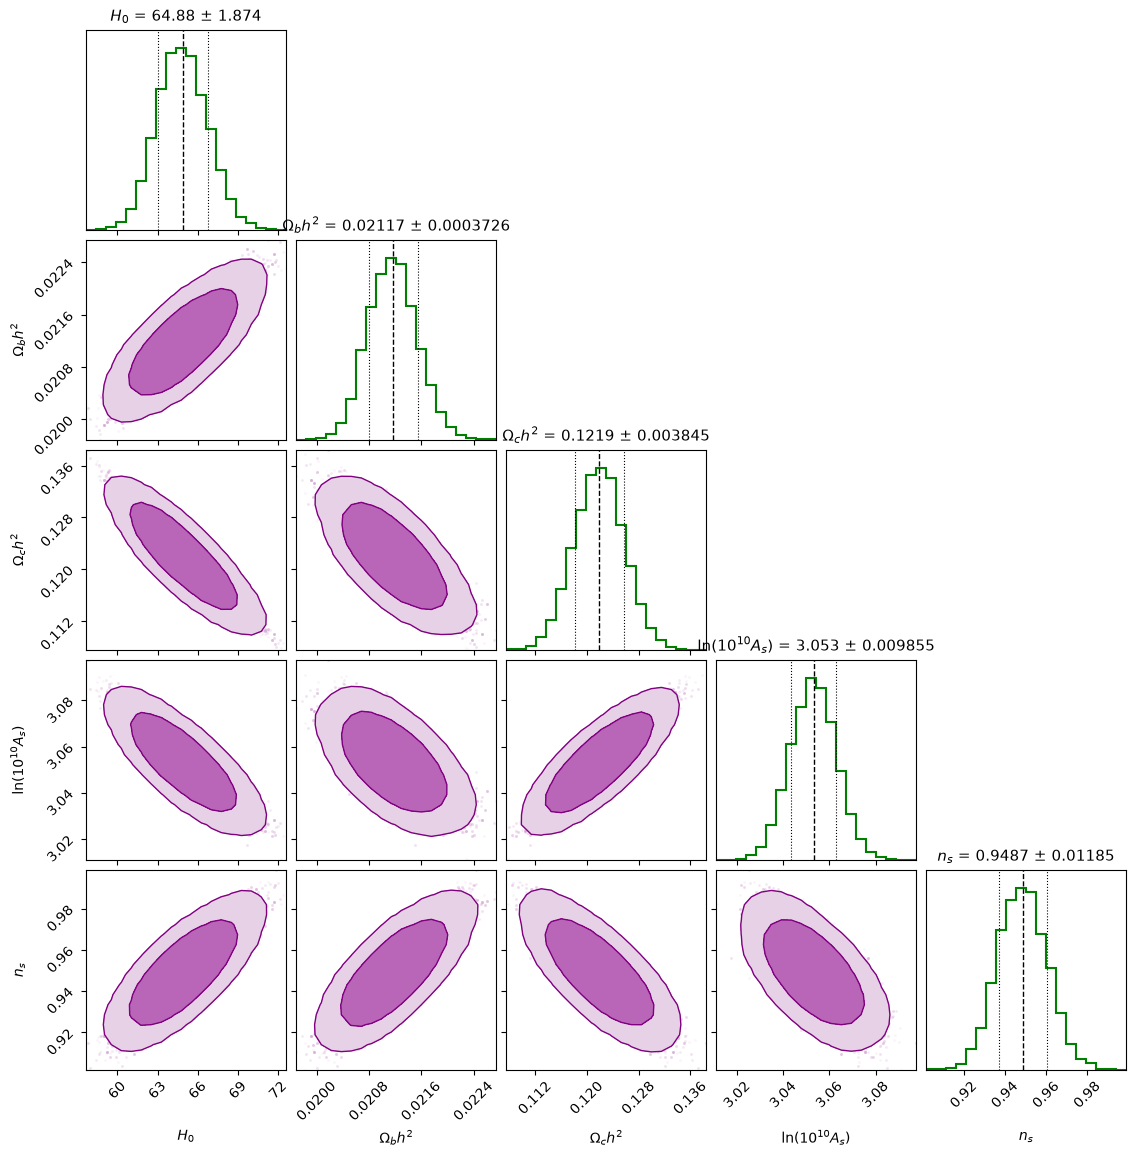

In [20]:
plot_names  = names[:-1]          # drop A_N, it's a nuisance parameter
plot_labels = labels[:-1]

samples = post[plot_names].to_numpy()

# 2 sigma and 3 sigma in 2D
sigmas = np.array([2., 3.])
levels = 1.0 - np.exp(-0.5 * sigmas**2)   # -> [0.8647, 0.9889]

figure = corner.corner(samples, color='purple',
    levels=levels,
    labels=plot_labels,
    fill_contours=True,
    plot_datapoints=True,
    plot_density=False,
    no_fill_contours=False,
    smooth=1.0,
    smooth1d=None,
    show_titles=False,
    hist_kwargs={"color": "green", "lw": 1.5},
    contour_kwargs={"linewidths": 1},
    contourf_kwargs={"colors": ['white', '#d8b3d8', '#8B008B'], "alpha": 0.6})

ndim = samples.shape[1]
axes = np.array(figure.axes).reshape((ndim, ndim))
mu = samples.mean(axis=0)
sd = samples.std(axis=0, ddof=1)

for i in range(ndim):
    ax = axes[i, i]
    ax.set_title(rf"{plot_labels[i]} = {mu[i]:.4g} $\pm$ {sd[i]:.4g}", fontsize=11)
    ax.axvline(mu[i], color='k', ls='--', lw=1)
    ax.axvline(mu[i] - sd[i], color='k', ls=':', lw=0.8)
    ax.axvline(mu[i] + sd[i], color='k', ls=':', lw=0.8)

figure.savefig("Saved Data/mcmc_cmb_corner_adaptive.png", dpi=200, bbox_inches="tight")


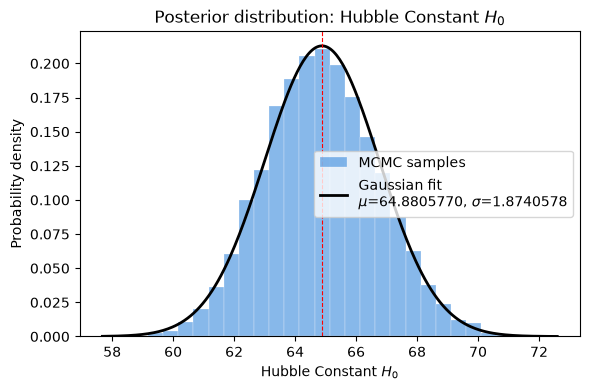

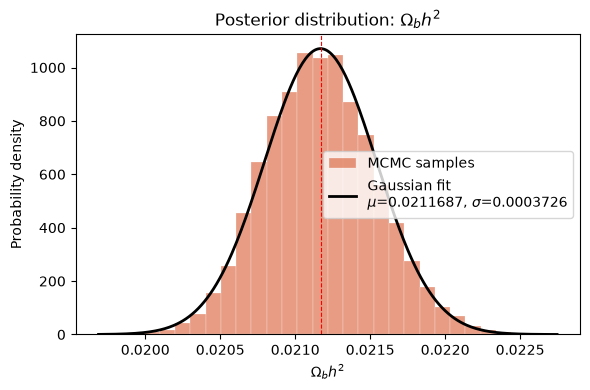

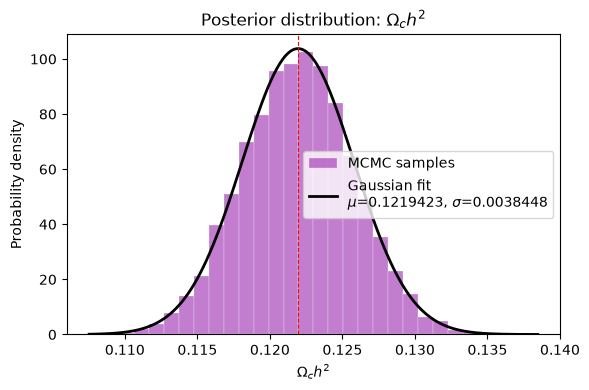

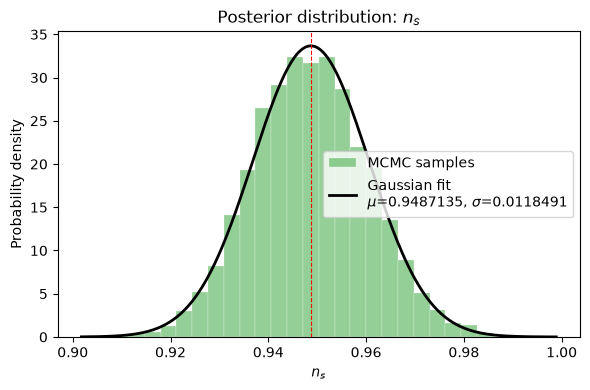

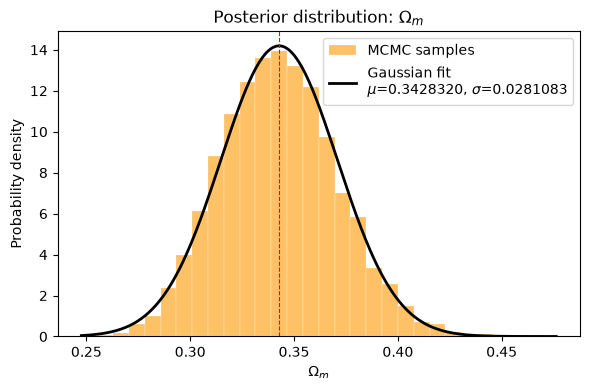

H0          = 64.88 +/- 1.87 km/s/Mpc
Omega_b h^2 = 0.02117 +/- 0.00037
Omega_c h^2 = 0.1219 +/- 0.0038
n_s         = 0.9487 +/- 0.0118
Omega_m     = 0.3428 +/- 0.0281   (derived)


In [ ]:
H0_mean,   H0_std   = plot_hist_with_gaussian(post['H0'], 'Hubble Constant $H_0$',
                                                color='#378ADD')
obh2_mean, obh2_std = plot_hist_with_gaussian(post['ombh2'], '$\\Omega_b h^2$',
                                                color='#D85A30')
och2_mean, och2_std = plot_hist_with_gaussian(post['omch2'], '$\\Omega_c h^2$',
                                                color='#9C27B0')
ns_mean,   ns_std   = plot_hist_with_gaussian(post['ns'], '$n_s$',
                                                color='#4CAF50')

# derived: total matter density
Om = (post['ombh2'] + post['omch2'] + 0.06/93.14) / (post['H0']/100)**2
Om_mean, Om_std = plot_hist_with_gaussian(Om, '$\\Omega_m$', color='#FF9800')

print(f"H0          = {H0_mean:.2f} +/- {H0_std:.2f} km/s/Mpc")
print(f"Omega_b h^2 = {obh2_mean:.5f} +/- {obh2_std:.5f}")
print(f"Omega_c h^2 = {och2_mean:.4f} +/- {och2_std:.4f}")
print(f"n_s         = {ns_mean:.4f} +/- {ns_std:.4f}")
print(f"Omega_m     = {Om_mean:.4f} +/- {Om_std:.4f}   (derived)")


Best fit: {'H0': np.float64(65.37891), 'ombh2': np.float64(0.02128), 'omch2': np.float64(0.121), 'logA': np.float64(3.05088), 'ns': np.float64(0.95112), 'A_N': np.float64(0.00055)}
chi_sq = 65.9 for 97 bandpowers, 91 dof


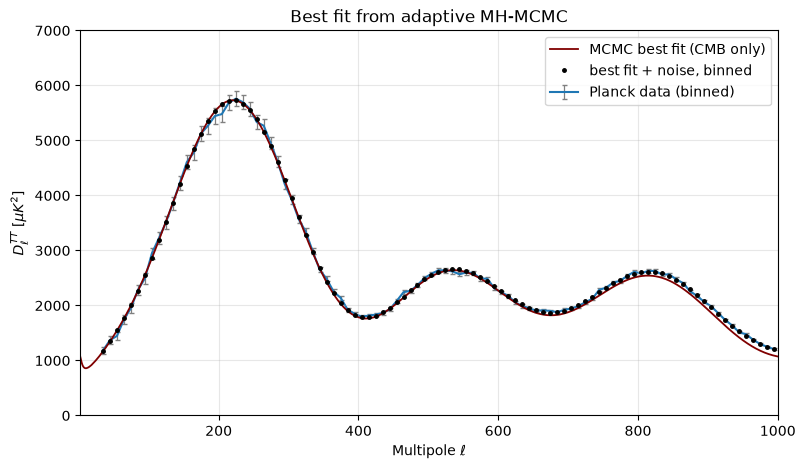

In [26]:
# best fit vs data
best = post.loc[post['Chi_sq'].idxmin(), names].to_numpy().astype(float)
print("Best fit:", dict(zip(names, np.round(best, 5))))
print(f"chi_sq = {chi2_at(best):.1f} for {len(l_eff)} bandpowers, {len(l_eff)-len(bounds)} dof") 

plt.figure(figsize=(9, 5))
plt.errorbar(l_eff, D_data, yerr=sig_b, mfc='deepskyblue',mec='none', ms=4,
             ecolor='gray', capsize=1.8, elinewidth=0.9, label='Planck data (binned)', zorder=1) 
plt.plot(l_arr[2:], CAMB_DL(*best[:5])[2:], color='maroon', lw=1.3,
         label='MCMC best fit (CMB only)', zorder=2)
plt.plot(l_eff, MODEL(best), 'k.', ms=5, label='best fit + noise, binned', zorder=3)

plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$D_\ell^{TT}\ [\mu K^2]$')
plt.title('Best fit from adaptive MH-MCMC')
plt.xlim(2, LMAX); plt.ylim(0, 7000)
plt.legend(); plt.grid(True, alpha=0.3)
plt.savefig("Saved Data/mcmc_cmb_bestfit_adaptive.png", dpi=300, bbox_inches="tight")
plt.show()


## Note on Computation Speed

Almost all the runtime is CAMB -- the Python around it is microseconds. Measured on this
machine: 1 thread 1.53 s, 2 threads 0.90 s, 4 threads 0.52 s, 12 threads 0.31 s per call.

`OMP_NUM_THREADS` is set in the first cell, **above `import camb`**. It only takes effect at
import time, so after changing it the kernel must be fully restarted -- re-running the cell
does nothing.

At 0.31 s/step, 10000 steps is roughly 52 minutes. If that's still too slow, `LMAX = 700`
roughly halves the cost again (CAMB scales about as $\ell_{\max}^2$), at the price of losing
the third acoustic peak.

---
# Conclusion

Adapting the proposal covariance on the fly replaces the pilot run of `CMB_MCMC.ipynb`.
Only post-`ADAPT_STOP` samples are kept, so the retained portion comes from one fixed
proposal.

| Parameter | This fit | Planck 2018 |
|---|---|---|
| $H_0$ | $64.96 \pm 1.86$ | $67.4$ |
| $\Omega_b h^2$ | $0.02117 \pm 0.00037$ | $0.0224$ |
| $\Omega_c h^2$ | $0.1218 \pm 0.0038$ | $0.120$ |
| $n_s$ | $0.9489 \pm 0.0119$ | $0.965$ |

Best fit $H_0 = 65.38$ with $\chi^2 = 65.9$ for 91 dof.

**The fit is good, and that itself is informative.**

$$\frac{\chi^2}{\rm dof} = \frac{65.9}{91} = 0.72 < 1$$

meaning the bandpower errors are conservative. They are dominated by cosmic variance,

$$\frac{\Delta C_\ell}{C_\ell} = \sqrt{\frac{2}{(2\ell+1)f_{\rm sky}}}$$

with no instrumental or foreground term added. The model is not being strained.

**$H_0$ sits $\approx 1.3\sigma$ below Planck, and $\Omega_b h^2$, $n_s$ are low by a few
$\sigma$.** This is a biased spectrum, not a biased sampler: the mask correlates multipoles
and $1/f_{\rm sky}$ only approximately undoes it, foreground residuals get absorbed into
$A_N$, and the noise is neither white nor uniform. Fixing it needs MASTER, not a longer chain.

Headline: $H_0 \approx 65$ from the early universe, against $\approx 70$ from Pantheon in
`SNe/`. That gap is the Hubble tension.